<p align="center"><a href="https://www.fiap.com.br/"><img src="https://raw.githubusercontent.com/agodoi/templateFiapVfinal/main/assets/logo-fiap.png" alt="FIAP" width="40%"></a></p>

# FarmTech Solutions | Previsão de Rendimento de Safra e Tendências de Produtividade

**PBL Fase 5 — "Machine Learning na Cabeça"** · Curso de Inteligência Artificial · FIAP · Turma 1TIAOB

| | |
|---|---|
| **Aluno** | Willian Kauê Tobias do Carmo |
| **RM** | 570038 |
| **Grupo** | 48 |
| **Entrega** | Entrega 1 — Machine Learning (análise exploratória, clusterização, outliers e 5 modelos preditivos) |
| **Dataset** | `crop_yield.csv` (156 registros, 4 culturas, 4 variáveis climáticas, rendimento) |

> **Como ler este notebook:** cada seção começa com um texto curto explicando *o que* será feito e *por quê*; depois vem o código comentado linha a linha; e termina com um bloco **Achados** interpretando os resultados. A seção 8 consolida conclusões, pontos fortes e limitações.

## Resultados em 30 segundos

| Pergunta do enunciado | Resposta encontrada |
|---|---|
| O que há na base? | 156 registros = **39 cenários climáticos × 4 culturas** (cacau, dendê, arroz, borracha) de uma mesma localidade tropical; sem nulos nem duplicatas. O rendimento está em **hg/ha** (padrão FAO), não em t/ha como descrito no enunciado. |
| Existem cenários discrepantes? | **Não há outliers de rendimento** (IQR e z-score). Isolation Forest e DBSCAN apenas destacam os anos climáticos extremos (cenários 2, 4, 28 e 39), mantidos na análise. |
| Quais as tendências de produtividade? | **Três regimes climáticos** (K-Means, k=3, silhueta 0,40). O regime quente favorece o arroz (+11%) e penaliza a borracha (-13%); o regime seco e mais fresco faz o inverso (borracha +14%, arroz -16%); o regime úmido é neutro. Não existe "ano bom" universal. |
| Os 5 modelos preveem o rendimento? | Sim. Em validação aninhada por cenário, **Random Forest** é o melhor (MAPE 11,3% vs 14,2% do baseline "média da cultura"; R² relativo 0,20), seguido de Gradient Boosting (11,7%) e Árvore de Decisão (11,9%). Regressão Linear (13,9%) e SVR (13,7%) empatam com o baseline. |
| Principal limitação | Há uma **tendência temporal** (tecnológica) que o clima não explica: incluindo a posição na sequência, o erro do Random Forest cai para 8,2% e o R² relativo sobe para 0,51. |

## 1. Contexto de negócio e objetivos

A **FarmTech Solutions** presta serviços de IA para uma fazenda de médio porte (200 hectares, cerca de 210 campos de futebol) que produz várias culturas. O cliente quer duas coisas:

1. **Prever o rendimento da safra** (toneladas por hectare) a partir das condições climáticas e da cultura plantada, para apoiar decisões de plantio, insumos e logística.
2. **Entender tendências de produtividade**: existem regimes climáticos que se repetem? Quais deles favorecem cada cultura? Há cenários discrepantes (outliers) que merecem atenção?

Traduzindo para Machine Learning, o problema tem duas frentes:

| Frente | Técnica | Capítulo de referência |
|---|---|---|
| Descobrir estrutura nos dados (tendências, grupos, anomalias) | Aprendizado **não supervisionado**: K-Means, agrupamento hierárquico, DBSCAN, Isolation Forest, PCA | Fase 5 — Cap. 10 *Machine Learning Sem Supervisão* |
| Prever uma variável contínua (rendimento) | Aprendizado **supervisionado** de regressão: 5 algoritmos distintos avaliados com métricas de erro | Fase 4 — Cap. 13 *Modelagem de Dados com Regressão Supervisionada* |

**Roteiro do trabalho:** setup → carga e dicionário de dados → análise exploratória → outliers → clusterização → 5 modelos preditivos → conclusões.

## 2. Setup do ambiente

Fixamos a semente aleatória (`RANDOM_STATE = 42`) para que todos os resultados sejam **reprodutíveis** e registramos as versões das bibliotecas, uma boa prática para quem for executar o notebook na correção. As dependências estão listadas em `src/requirements.txt`.

In [1]:
# Bibliotecas de manipulação de dados e cálculo numérico
import pandas as pd                      # dataframes
import numpy as np                       # álgebra e utilidades numéricas
import warnings, platform, sys, time     # utilidades do sistema

# Bibliotecas de visualização
import matplotlib.pyplot as plt          # gráficos base
import seaborn as sns                    # gráficos estatísticos

# Estatística
from scipy import stats                  # z-score e testes
from scipy.cluster.hierarchy import dendrogram, linkage  # agrupamento hierárquico

# Scikit-learn: pré-processamento, modelos e avaliação
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error, silhouette_score)
from sklearn.inspection import permutation_importance

# Configurações globais
RANDOM_STATE = 42                        # semente única para reprodutibilidade
warnings.filterwarnings("ignore")        # silencia avisos que só poluem a leitura
sns.set_theme(style="whitegrid", palette="viridis")  # estilo visual padrão
plt.rcParams["figure.dpi"] = 100         # resolução das figuras
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")  # formatação numérica
T0 = time.time()                         # marca o início para medir o tempo total de execução

# Registro do ambiente (útil para reprodutibilidade na correção)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}")

Python 3.10.12 | pandas 2.3.3 | numpy 2.2.6 | scikit-learn 1.7.2 | matplotlib 3.10.9 | seaborn 0.13.2


## 3. Carga dos dados e dicionário de variáveis

O arquivo `crop_yield.csv` está versionado na pasta `assets/` do repositório. A função abaixo procura o arquivo em caminhos relativos (executando de `src/` ou da raiz) e, como último recurso, tenta o *raw* do GitHub, o que permite rodar o notebook também no Google Colab.

Renomeamos as colunas para nomes curtos em português, mantendo o dicionário original para referência.

In [2]:
# Possíveis localizações do dataset (execução a partir de src/, da raiz do repo ou do Colab)
CAMINHOS = ["../assets/crop_yield.csv", "assets/crop_yield.csv", "crop_yield.csv",
            "https://raw.githubusercontent.com/willktdc/fiap-ia-fase5-farmtech-grupo48/main/assets/crop_yield.csv"]

def carregar_dados(caminhos):
    """Percorre a lista de caminhos e devolve o primeiro DataFrame carregado com sucesso."""
    for c in caminhos:                                   # tenta cada caminho em ordem
        try:
            df = pd.read_csv(c)                          # leitura do CSV
            print(f"Dataset carregado de: {c}")          # informa a origem usada
            return df
        except Exception:                                # caminho inexistente: tenta o próximo
            continue
    raise FileNotFoundError("crop_yield.csv não encontrado em nenhum dos caminhos.")

df_raw = carregar_dados(CAMINHOS)                        # DataFrame original (intocado)

# Dicionário: nome original -> nome curto usado no notebook
RENOMEAR = {
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)": "umidade_especifica",
    "Relative Humidity at 2 Meters (%)": "umidade_relativa",
    "Temperature at 2 Meters (C)": "temperatura",
    "Yield": "rendimento",
}
df = df_raw.rename(columns=RENOMEAR).copy()             # cópia de trabalho com nomes curtos
CLIMA = ["precipitacao", "umidade_especifica", "umidade_relativa", "temperatura"]  # variáveis explicativas numéricas
ALVO = "rendimento"                                      # variável resposta

print(f"Dimensão: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado de: ../assets/crop_yield.csv
Dimensão: 156 linhas x 6 colunas


,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


### 3.1 Dicionário de dados

| Coluna (curta) | Coluna original | Descrição | Unidade declarada |
|---|---|---|---|
| `cultura` | Crop | Cultura agrícola avaliada | categórica |
| `precipitacao` | Precipitation (mm day-1) | Volume de chuva | mm/dia (ver observação) |
| `umidade_especifica` | Specific Humidity at 2 Meters (g/kg) | Vapor d'água por kg de ar seco, a 2 m do solo | g/kg |
| `umidade_relativa` | Relative Humidity at 2 Meters (%) | Percentual de saturação do ar, a 2 m do solo | % |
| `temperatura` | Temperature at 2 Meters (C) | Temperatura do ar a 2 m do solo | °C |
| `rendimento` | Yield | Rendimento da safra | t/ha (ver observação) |

**Observação sobre unidades (achado importante):** o enunciado descreve o rendimento em *toneladas por hectare*, mas os valores observados (por exemplo, cacau entre 5.765 e 13.056; dendê acima de 140.000) são incompatíveis com t/ha e compatíveis com **hg/ha (hectogramas por hectare)**, a unidade padrão da base FAOSTAT da qual esse tipo de dado costuma derivar. Dividindo por 10.000 obtemos valores agronomicamente plausíveis (cacau ≈ 0,9 t/ha, arroz ≈ 3,2 t/ha, dendê ≈ 17,6 t/ha, borracha ≈ 0,8 t/ha). O mesmo vale para a precipitação: valores entre 1.900 e 3.100 "mm/dia" só fazem sentido como **acumulado anual em mm**. Criamos a coluna `rendimento_t_ha` apenas para leitura de negócio; **a modelagem usa a escala original**, já que transformações lineares não alteram o ajuste dos modelos, apenas a leitura das métricas.

In [3]:
# Coluna auxiliar em toneladas/hectare (hg/ha ÷ 10.000) para leitura de negócio
df["rendimento_t_ha"] = df[ALVO] / 10_000

# Tabela de plausibilidade: rendimento médio em cada unidade, por cultura
plaus = (df.groupby("cultura")[[ALVO, "rendimento_t_ha"]].mean()
           .rename(columns={ALVO: "media (escala original)", "rendimento_t_ha": "media (t/ha)"}))
plaus

,media (escala original),media (t/ha)
cultura,,
"Cocoa, beans","8,883.13",0.89
Oil palm fruit,"175,804.69",17.58
"Rice, paddy","32,099.67",3.21
"Rubber, natural","7,824.90",0.78


## 4. Análise exploratória (EDA)

Objetivo: conhecer a estrutura da base antes de modelar. Verificamos tipos, valores ausentes, duplicatas, distribuição de cada variável, diferenças entre culturas e correlações. Cada bloco termina com os achados.

### 4.1 Estrutura, qualidade e balanceamento

In [4]:
# Tipos de dados e contagem de não nulos
df.info()

# Resumo de qualidade em uma linha por métrica
qualidade = pd.Series({
    "valores ausentes": int(df.isna().sum().sum()),          # total de células vazias
    "linhas duplicadas": int(df.duplicated().sum()),          # registros repetidos
    "culturas distintas": df["cultura"].nunique(),            # quantidade de categorias
})
print("\nQualidade:\n", qualidade.to_string())

# Balanceamento das culturas (quantidade de registros por categoria)
print("\nRegistros por cultura:\n", df["cultura"].value_counts().to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cultura             156 non-null    object 
 1   precipitacao        156 non-null    float64
 2   umidade_especifica  156 non-null    float64
 3   umidade_relativa    156 non-null    float64
 4   temperatura         156 non-null    float64
 5   rendimento          156 non-null    int64  
 6   rendimento_t_ha     156 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 8.7+ KB

Qualidade:
 valores ausentes      0
linhas duplicadas     0
culturas distintas    4

Registros por cultura:
 cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39


### 4.2 Estatísticas descritivas

In [5]:
# Estatísticas descritivas gerais das variáveis numéricas
display(df[CLIMA + [ALVO]].describe().T)

# Estatísticas do rendimento por cultura (a escala muda muito entre culturas)
resumo_cultura = df.groupby("cultura")[ALVO].agg(["count", "mean", "std", "min", "median", "max"])
resumo_cultura["cv_%"] = 100 * resumo_cultura["std"] / resumo_cultura["mean"]   # coeficiente de variação
display(resumo_cultura)

,count,mean,std,min,25%,50%,75%,max
precipitacao,156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
umidade_especifica,156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
umidade_relativa,156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
temperatura,156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
rendimento,156.00,"56,153.10","70,421.96","5,249.00","8,327.75","18,871.00","67,518.75","203,399.00"


,count,mean,std,min,median,max,cv_%
cultura,,,,,,,
"Cocoa, beans",39,"8,883.13","1,745.03",5765,"8,848.00",13056,19.64
Oil palm fruit,39,"175,804.69","14,919.87",142425,"175,629.00",203399,8.49
"Rice, paddy",39,"32,099.67","4,789.95",24686,"31,101.00",42550,14.92
"Rubber, natural",39,"7,824.90","1,600.26",5249,"7,817.00",10285,20.45


### 4.3 Distribuições

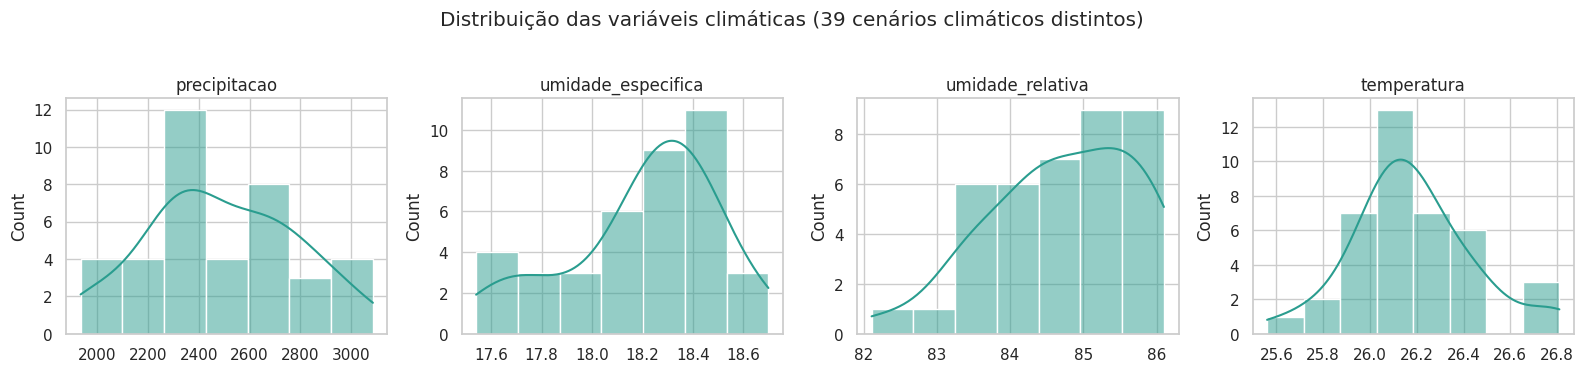

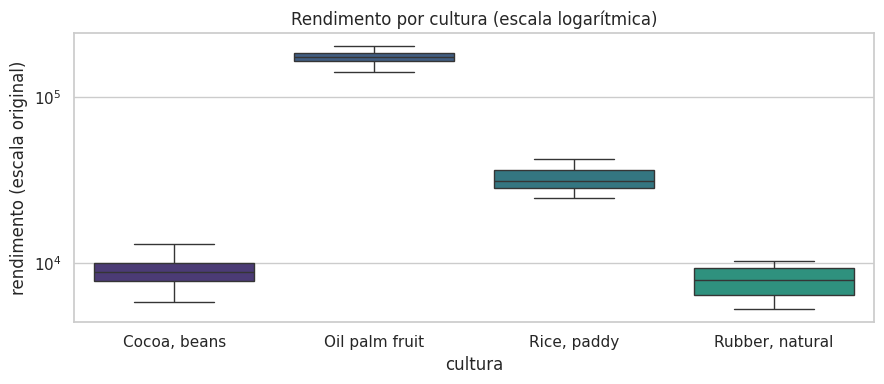

In [6]:
# Histogramas das variáveis climáticas (cada valor climático aparece 4x, uma por cultura; usamos valores únicos)
clima_unico = df[CLIMA].drop_duplicates().reset_index(drop=True)   # cenários climáticos distintos
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, col in zip(axes, CLIMA):
    sns.histplot(clima_unico[col], kde=True, ax=ax, color="#2a9d8f")   # histograma + curva de densidade
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle(f"Distribuição das variáveis climáticas ({len(clima_unico)} cenários climáticos distintos)", y=1.03)
plt.tight_layout(); plt.show()

# Boxplot do rendimento por cultura em escala log (as culturas têm ordens de grandeza diferentes)
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="cultura", y=ALVO, hue="cultura", legend=False, ax=ax)
ax.set_yscale("log"); ax.set_title("Rendimento por cultura (escala logarítmica)"); ax.set_ylabel("rendimento (escala original)")
plt.tight_layout(); plt.show()

### 4.4 Achado estrutural: os mesmos 39 cenários climáticos para as 4 culturas

Ao contar os valores únicos, percebemos que as 156 linhas são, na prática, **39 cenários climáticos × 4 culturas**: cada combinação de precipitação, umidade e temperatura aparece exatamente uma vez para cada cultura. Ou seja, a base descreve **uma mesma localidade em 39 períodos** (provavelmente 39 anos, dado o padrão FAO 1980–2018), com o rendimento de quatro culturas em cada período. Isso tem três consequências para o projeto:

1. A variável `cultura` explica a maior parte da variância do rendimento (escalas muito diferentes), então precisa entrar no modelo e as métricas devem ser lidas **por cultura**.
2. Correlações calculadas na base inteira ficam próximas de zero e enganam; a análise correta é **por cultura**.
3. A clusterização de "tendências" faz mais sentido sobre os **39 cenários climáticos**, medindo depois o rendimento médio de cada cultura em cada cluster.

In [7]:
# Verificação: o bloco de clima de cada cultura é idêntico ao das demais?
blocos = {c: df.loc[df.cultura == c, CLIMA].reset_index(drop=True) for c in df.cultura.unique()}
culturas = list(blocos)
identicos = all(blocos[culturas[0]].equals(blocos[c]) for c in culturas[1:])   # compara todos com o primeiro
print(f"Cenários climáticos distintos: {len(clima_unico)}  |  blocos climáticos idênticos entre culturas: {identicos}")

# Índice do cenário (1..39) dentro de cada cultura: usado adiante para ler tendências ao longo da sequência
df["cenario"] = df.groupby("cultura").cumcount() + 1

Cenários climáticos distintos: 39  |  blocos climáticos idênticos entre culturas: True


### 4.5 Correlações: visão global versus visão por cultura

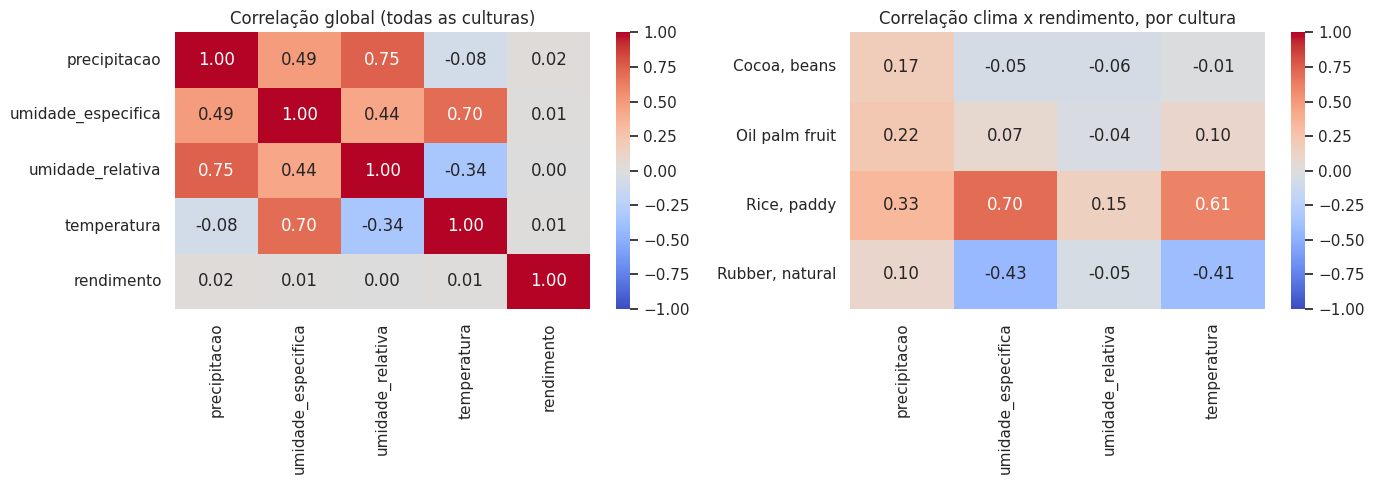

In [8]:
# Heatmap de correlação global (todas as culturas juntas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[CLIMA + [ALVO]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlação global (todas as culturas)")

# Correlação de cada variável climática com o rendimento, calculada dentro de cada cultura
corr_cultura = pd.DataFrame({c: df.loc[df.cultura == c, CLIMA + [ALVO]].corr()[ALVO].drop(ALVO)
                             for c in sorted(df.cultura.unique())}).T          # uma linha por cultura
sns.heatmap(corr_cultura, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlação clima x rendimento, por cultura")
plt.tight_layout(); plt.show()

### 4.6 Tendência ao longo da sequência de cenários
Não há coluna de ano, mas a ordem dos registros segue o padrão de séries FAO. Tratamos a posição do cenário (1 a 39) como **hipótese de ordem cronológica** e observamos como o rendimento evolui.

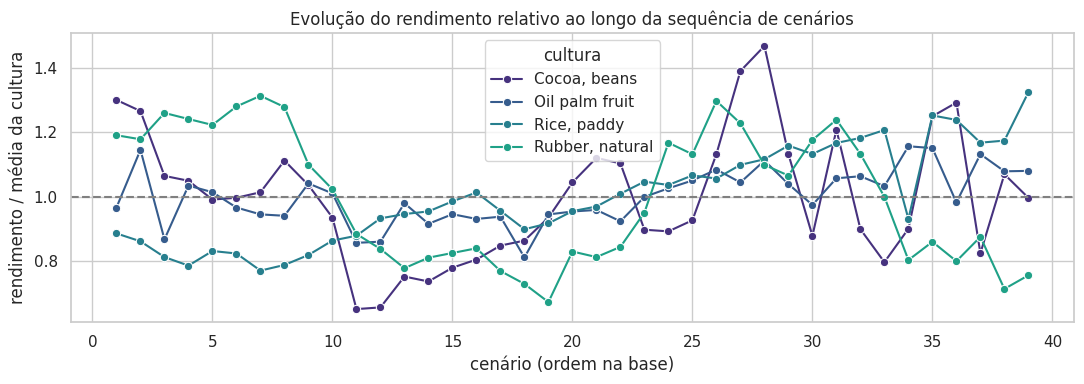

Correlação de Spearman (posição x rendimento), por cultura:
 Cocoa, beans       0.06
Oil palm fruit     0.53
Rice, paddy        0.91
Rubber, natural   -0.38

Correlação de Spearman (posição x clima):
 precipitacao         0.43
umidade_especifica   0.80
umidade_relativa     0.21
temperatura          0.67


In [9]:
# Rendimento normalizado pela média da cultura (=1,0), para colocar as 4 culturas no mesmo gráfico
df["rendimento_rel"] = df[ALVO] / df.groupby("cultura")[ALVO].transform("mean")

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=df, x="cenario", y="rendimento_rel", hue="cultura", marker="o", ax=ax)
ax.axhline(1, ls="--", c="gray"); ax.set_ylabel("rendimento / média da cultura"); ax.set_xlabel("cenário (ordem na base)")
ax.set_title("Evolução do rendimento relativo ao longo da sequência de cenários")
plt.tight_layout(); plt.show()

# Correlação de Spearman entre a posição na sequência e o rendimento, por cultura (tendência monotônica?)
tend = pd.Series({c: stats.spearmanr(df.loc[df.cultura == c, "cenario"], df.loc[df.cultura == c, ALVO]).statistic
                  for c in sorted(df.cultura.unique())})
print("Correlação de Spearman (posição x rendimento), por cultura:\n", tend.round(2).to_string())

# O clima também muda ao longo da sequência? (Spearman posição x variável climática, nos 39 cenários)
clima_seq = clima_unico.copy(); clima_seq["cenario"] = range(1, len(clima_seq) + 1)
tend_clima = pd.Series({c: stats.spearmanr(clima_seq["cenario"], clima_seq[c]).statistic for c in CLIMA})
print("\nCorrelação de Spearman (posição x clima):\n", tend_clima.round(2).to_string())

**Achados da EDA**

- Base limpa: 156 registros, sem valores ausentes nem duplicatas, quatro culturas perfeitamente balanceadas (39 registros cada).
- A escala do rendimento varia em mais de 20x entre culturas (dendê ≈ 175,8 mil vs. borracha ≈ 7,8 mil). Por isso a cultura é a variável mais importante e todas as métricas de erro serão lidas também por cultura. A variabilidade relativa (CV) é maior na borracha (20%) e no cacau (20%) e menor no dendê (8%).
- O clima é pouco variável: temperatura entre 25,6 e 26,8 °C, umidade relativa entre 82 e 86%. É um clima tropical úmido estável; a maior variabilidade está na precipitação (1.935 a 3.086 mm acumulados).
- Correlações globais são ~0 por causa do efeito da cultura; por cultura, o **arroz responde positivamente à temperatura (r ≈ 0,6) e à precipitação (≈ 0,3)**, enquanto a **borracha responde negativamente à temperatura (≈ -0,4)**. Cacau e dendê têm relação fraca com o clima medido.
- Há uma tendência forte ao longo da sequência: o rendimento do **arroz cresce quase monotonicamente (Spearman 0,91)** e o do dendê também (0,53), enquanto a borracha cai (-0,38). Como não há coluna de ano, interpretamos isso como um **componente tecnológico/temporal** (variedades e manejo) que não está representado pelas variáveis climáticas. Agravante: **temperatura e umidade específica também crescem ao longo da série** (Spearman 0,67 e 0,80), então parte da correlação clima-rendimento pode ser efeito do tempo. Essa é a limitação estrutural mais importante da base e volta nas seções 6, 7 e 8.

## 5. Cenários discrepantes (outliers)

Usamos quatro lentes complementares, sempre **dentro de cada cultura** (comparar cacau com dendê não faz sentido):

1. **IQR (boxplot)**: valores fora de [Q1 − 1,5·IQR, Q3 + 1,5·IQR].
2. **Z-score**: |z| > 3 em relação à média da cultura.
3. **Isolation Forest** (Cap. 10): método multivariado não supervisionado que isola pontos "fáceis de separar" no espaço clima + rendimento relativo.
4. **DBSCAN** (Cap. 10): método baseado em densidade; cenários climáticos que não pertencem a nenhuma região densa são rotulados como ruído (-1).

In [10]:
# 1) IQR por cultura, aplicado ao rendimento
def outliers_iqr(serie):
    '''Retorna máscara booleana dos pontos fora dos limites de Tukey (1,5 x IQR).'''
    q1, q3 = serie.quantile([0.25, 0.75])            # quartis
    iqr = q3 - q1                                     # amplitude interquartil
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

df["out_iqr"] = df.groupby("cultura")[ALVO].transform(outliers_iqr)

# 2) Z-score por cultura (|z| > 3)
df["z_rend"] = df.groupby("cultura")[ALVO].transform(lambda s: stats.zscore(s, ddof=1))
df["out_z"] = df["z_rend"].abs() > 3

# 3) Isolation Forest multivariado (clima + rendimento relativo), contaminação esperada de 5%
X_iso = StandardScaler().fit_transform(df[CLIMA + ["rendimento_rel"]])       # padroniza as variáveis
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE).fit(X_iso)
df["score_iso"] = iso.decision_function(X_iso)                                # quanto menor, mais anômalo
df["out_iso"] = iso.predict(X_iso) == -1                                      # -1 = anomalia

# 4) DBSCAN sobre os 39 cenários climáticos padronizados (eps escolhido pelo gráfico de k-distâncias abaixo)
Xc_out = StandardScaler().fit_transform(clima_unico[CLIMA])
db = DBSCAN(eps=1.4, min_samples=4).fit(Xc_out)
clima_unico["dbscan"] = db.labels_                                            # -1 = ruído (baixa densidade)
cenarios_ruido = (np.where(db.labels_ == -1)[0] + 1).tolist()

resumo_out = pd.DataFrame({"IQR": [int(df.out_iqr.sum())], "Z-score": [int(df.out_z.sum())],
                           "Isolation Forest": [int(df.out_iso.sum())], "DBSCAN (cenários)": [len(cenarios_ruido)]},
                          index=["nº de pontos discrepantes"])
display(resumo_out)
print("Cenários de baixa densidade segundo o DBSCAN:", cenarios_ruido)

# Detalhe dos pontos apontados pelo Isolation Forest
cols_show = ["cultura", "cenario"] + CLIMA + [ALVO, "rendimento_rel", "z_rend", "score_iso"]
display(df.loc[df.out_iso, cols_show].sort_values("score_iso"))

,IQR,Z-score,Isolation Forest,DBSCAN (cenários)
nº de pontos discrepantes,0,0,8,4


Cenários de baixa densidade segundo o DBSCAN: [2, 18, 36, 39]


,cultura,cenario,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento,rendimento_rel,z_rend,score_iso
79,"Rice, paddy",2,"1,938.42",17.54,82.11,26.11,27619,0.86,-0.94,-0.05
1,"Cocoa, beans",2,"1,938.42",17.54,82.11,26.11,11253,1.27,1.36,-0.04
27,"Cocoa, beans",28,"3,085.79",18.34,86.10,26.03,13056,1.47,2.39,-0.04
81,"Rice, paddy",4,"2,592.35",17.61,85.07,25.56,25187,0.78,-1.44,-0.02
120,"Rubber, natural",4,"2,592.35",17.61,85.07,25.56,9718,1.24,1.18,-0.01
116,"Rice, paddy",39,"2,109.34",18.51,83.52,26.72,42550,1.33,2.18,-0.01
40,Oil palm fruit,2,"1,938.42",17.54,82.11,26.11,201436,1.15,1.72,-0.01
118,"Rubber, natural",2,"1,938.42",17.54,82.11,26.11,9223,1.18,0.87,-0.00


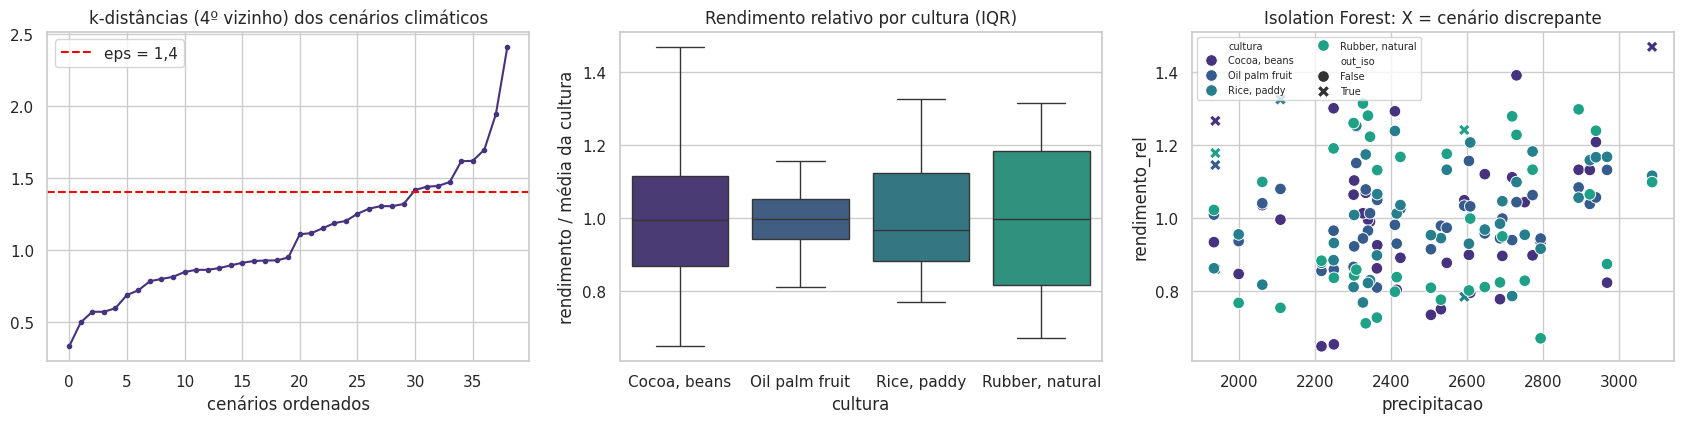

In [11]:
# Gráfico de k-distâncias (apoio à escolha do eps do DBSCAN) e visualizações dos outliers
from sklearn.neighbors import NearestNeighbors
dist_k, _ = NearestNeighbors(n_neighbors=4).fit(Xc_out).kneighbors(Xc_out)   # distância ao 4º vizinho
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
axes[0].plot(np.sort(dist_k[:, -1]), marker="."); axes[0].axhline(1.4, ls="--", c="red", label="eps = 1,4")
axes[0].set_title("k-distâncias (4º vizinho) dos cenários climáticos"); axes[0].set_xlabel("cenários ordenados"); axes[0].legend()

sns.boxplot(data=df, x="cultura", y="rendimento_rel", hue="cultura", legend=False, ax=axes[1])
axes[1].set_title("Rendimento relativo por cultura (IQR)"); axes[1].set_ylabel("rendimento / média da cultura")

sns.scatterplot(data=df, x="precipitacao", y="rendimento_rel", hue="cultura", style="out_iso",
                markers={False: "o", True: "X"}, s=70, ax=axes[2])
axes[2].set_title("Isolation Forest: X = cenário discrepante"); axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**Achados sobre outliers e decisão**

- Pelo critério IQR e pelo z-score **não há outliers de rendimento** em nenhuma cultura: as variações ficam dentro do esperado para séries agrícolas (coeficiente de variação entre 8% e 20%).
- O Isolation Forest, por construção, marca ~5% dos pontos (8 registros) como os mais "isolados". Eles se concentram em poucos cenários climáticos extremos: o **cenário 2** (menor precipitação, 1.938 mm, e menor umidade relativa, 82,1%), o **cenário 4** (menor temperatura, 25,6 °C), o **cenário 28** (maior precipitação, 3.086 mm) e o **cenário 39** (o mais quente, com o maior rendimento de arroz). O DBSCAN converge para o mesmo diagnóstico: os cenários 2, 18, 36 e 39 ficam fora da região densa do espaço climático.
- São **cenários extremos legítimos**, não erros de medição: nenhum valor é fisicamente implausível e os mesmos cenários aparecem para as quatro culturas (a base é consistente).
- **Decisão:** manter todos os registros. Com apenas 39 cenários por cultura, remover pontos reduziria a informação justamente sobre os anos climáticos extremos, que são os mais relevantes para uma ferramenta de apoio à decisão agrícola. A robustez a esses pontos é tratada pela transformação logarítmica do alvo, pela escolha de modelos e pela validação cruzada.

## 6. Clusterização: tendências de produtividade

### 6.1 Regimes climáticos (K-Means nos 39 cenários)
Agrupamos os 39 cenários climáticos distintos (variáveis padronizadas com `StandardScaler`) para descobrir **regimes climáticos** recorrentes. Escolhemos o número de clusters combinando o método do cotovelo (inércia) com o coeficiente de silhueta, e validamos com um dendrograma hierárquico. Em seguida medimos o rendimento médio de cada cultura em cada regime: essa é a "tendência de produtividade" pedida no enunciado.

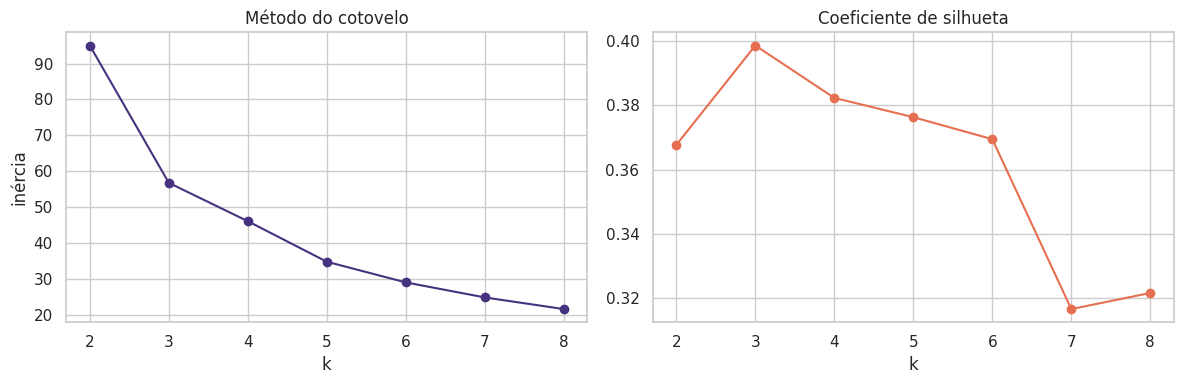

Silhueta por k: {2: 0.368, 3: 0.399, 4: 0.382, 5: 0.376, 6: 0.369, 7: 0.316, 8: 0.321}
k com maior silhueta: 3


In [12]:
# Matriz de cenários climáticos padronizada (média 0, desvio 1)
scaler_clima = StandardScaler()
Xc = scaler_clima.fit_transform(clima_unico[CLIMA])

# Varredura de k: inércia (cotovelo) e silhueta
ks = range(2, 9)
inercia, silhueta = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xc)   # n_init=20 evita mínimos locais
    inercia.append(km.inertia_)                                                # soma das distâncias intra-cluster
    silhueta.append(silhouette_score(Xc, km.labels_))                          # coesão x separação (-1 a 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inercia, marker="o"); axes[0].set_title("Método do cotovelo"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inércia")
axes[1].plot(list(ks), silhueta, marker="o", color="#e76f51"); axes[1].set_title("Coeficiente de silhueta"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

melhor_k = list(ks)[int(np.argmax(silhueta))]
print("Silhueta por k:", {k: round(float(s), 3) for k, s in zip(ks, silhueta)})
print(f"k com maior silhueta: {melhor_k}")

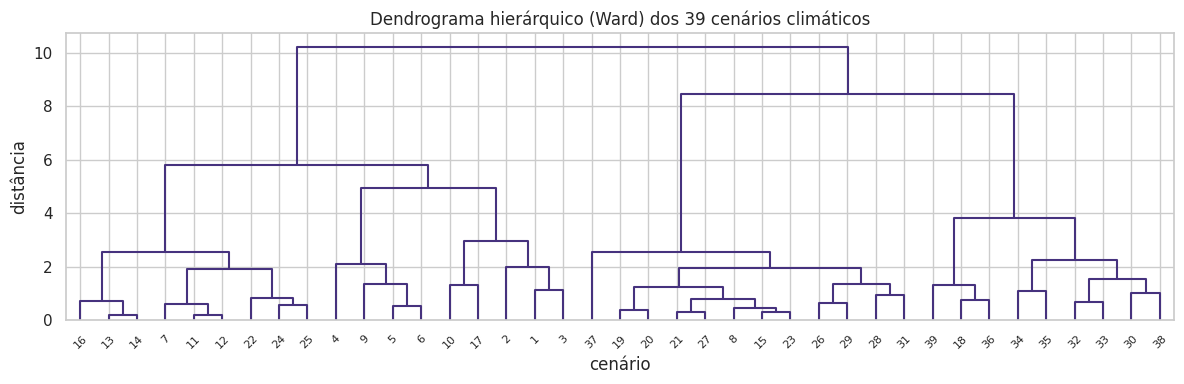

In [13]:
# Dendrograma (método de Ward) para validar visualmente a quantidade de grupos
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(linkage(Xc, method="ward"), labels=[str(i) for i in range(1, len(Xc) + 1)], ax=ax, color_threshold=0)
ax.set_title("Dendrograma hierárquico (Ward) dos 39 cenários climáticos"); ax.set_xlabel("cenário"); ax.set_ylabel("distância")
plt.tight_layout(); plt.show()

In [14]:
# Ajuste final do K-Means com k = 3 (maior silhueta, coerente com o cotovelo e com o dendrograma)
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, n_init=50, random_state=RANDOM_STATE).fit(Xc)
clima_unico["cluster"] = km_final.labels_                          # rótulo de cada cenário

# Perfil climático médio de cada cluster (na escala original) + posição média na sequência
perfil = clima_unico.groupby("cluster")[CLIMA].mean()
perfil["n_cenarios"] = clima_unico["cluster"].value_counts().sort_index()
clima_unico["cenario"] = range(1, len(clima_unico) + 1)               # posição do cenário na sequência
perfil["posicao_media"] = clima_unico.groupby("cluster")["cenario"].mean()
display(perfil.round(2))

# Propaga o cluster do cenário para as 156 linhas (via merge pelas 4 variáveis climáticas)
df = df.drop(columns=["cluster"], errors="ignore").merge(clima_unico[CLIMA + ["cluster"]], on=CLIMA, how="left")

# Rendimento médio de cada cultura em cada regime climático, relativo à média da cultura (1,00 = média)
tendencia = df.pivot_table(index="cluster", columns="cultura", values="rendimento_rel", aggfunc="mean")
display(tendencia.round(3))

,precipitacao,umidade_especifica,umidade_relativa,temperatura,n_cenarios,posicao_media
cluster,,,,,,
0,"2,733.52",18.34,85.65,26.12,17,22.53
1,"2,359.02",18.39,84.15,26.48,11,29.73
2,"2,232.22",17.81,83.92,25.99,11,6.36


cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,1.01,1.01,1.03,0.99
1,0.99,1.02,1.11,0.87
2,1.00,0.97,0.84,1.14


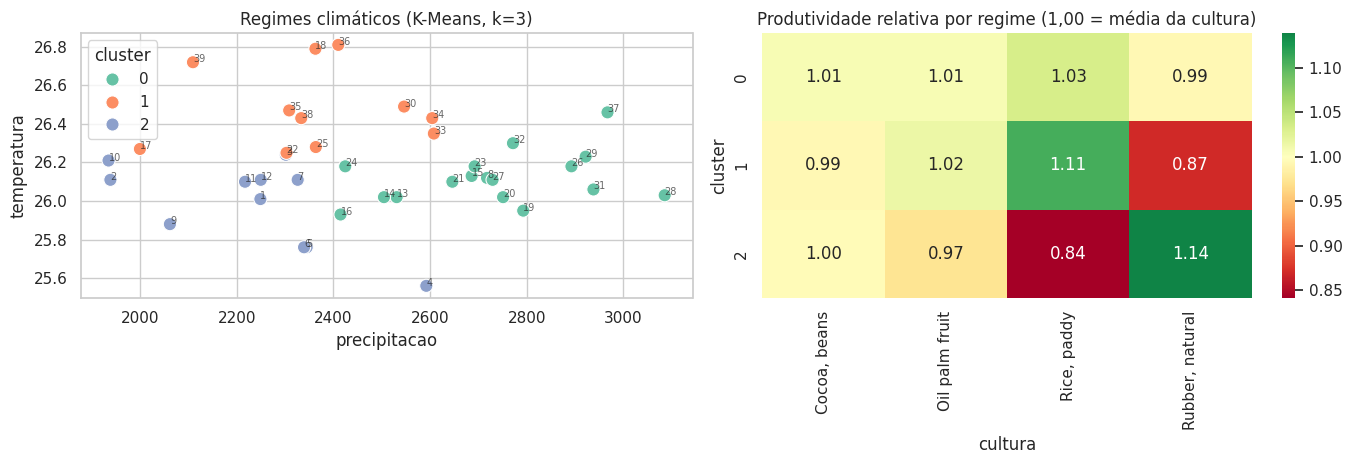

In [15]:
# Visualização dos regimes: dispersão precipitação x temperatura e heatmap de produtividade relativa
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.scatterplot(data=clima_unico, x="precipitacao", y="temperatura", hue="cluster", palette="Set2", s=90, ax=axes[0])
for i, r in clima_unico.iterrows():                                   # anota o número do cenário
    axes[0].annotate(int(i) + 1, (r.precipitacao, r.temperatura), fontsize=7, alpha=.7)
axes[0].set_title("Regimes climáticos (K-Means, k=3)")
sns.heatmap(tendencia, annot=True, fmt=".2f", cmap="RdYlGn", center=1, ax=axes[1])
axes[1].set_title("Produtividade relativa por regime (1,00 = média da cultura)")
plt.tight_layout(); plt.show()

### 6.2 Clima e rendimento no mesmo espaço: PCA e K-Means (156 registros)
Agora incluímos o rendimento relativo junto com o clima e projetamos em duas componentes principais. A pergunta é se emergem grupos de "anos bons" e "anos ruins" independentes da cultura e quanto do rendimento relativo é explicado pelos eixos climáticos.

Variância explicada pelas 2 componentes: [0.431 0.319] | total: 0.75


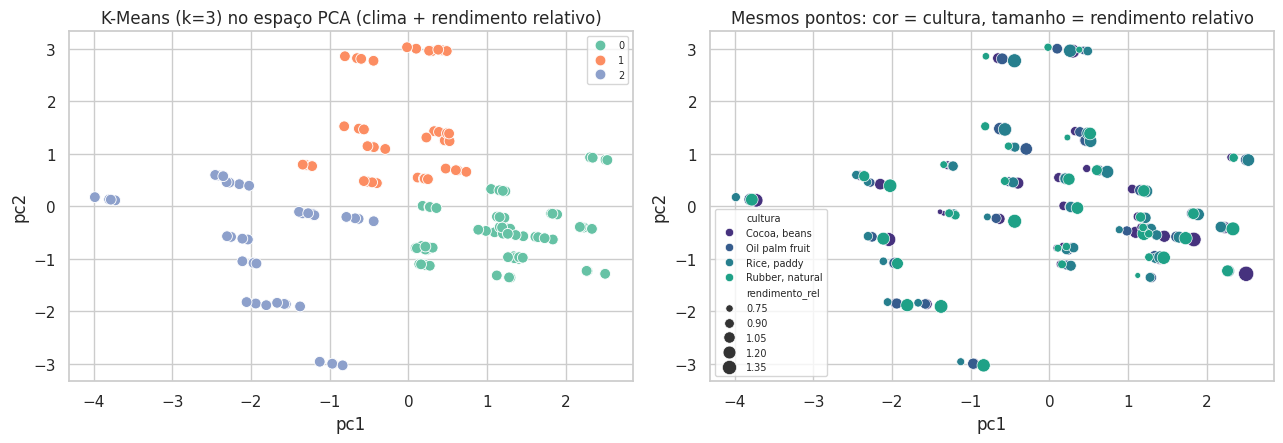

,PC1,PC2
precipitacao,0.60,-0.22
umidade_especifica,0.54,0.46
umidade_relativa,0.56,-0.38
temperatura,0.12,0.78
rendimento_rel,0.10,-0.02


In [16]:
# Espaço clima + rendimento relativo, padronizado
X_full = StandardScaler().fit_transform(df[CLIMA + ["rendimento_rel"]])

# PCA para visualização em 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(X_full)
df["pc1"], df["pc2"] = comp[:, 0], comp[:, 1]
print("Variância explicada pelas 2 componentes:", np.round(pca.explained_variance_ratio_, 3),
      "| total:", round(float(pca.explained_variance_ratio_.sum()), 3))

# K-Means (k=3) sobre o mesmo espaço
df["cluster_full"] = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(X_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="cluster_full", palette="Set2", s=60, ax=axes[0]); axes[0].set_title("K-Means (k=3) no espaço PCA (clima + rendimento relativo)")
sns.scatterplot(data=df, x="pc1", y="pc2", hue="cultura", size="rendimento_rel", sizes=(15, 120), ax=axes[1]); axes[1].set_title("Mesmos pontos: cor = cultura, tamanho = rendimento relativo")
for ax in axes: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Cargas (loadings) das componentes: o que cada eixo representa
display(pd.DataFrame(pca.components_.T, index=CLIMA + ["rendimento_rel"], columns=["PC1", "PC2"]).round(2))

**Achados da clusterização**

- Os 39 cenários climáticos se organizam em **três regimes** (k = 3 maximiza a silhueta, ≈ 0,40, e o dendrograma mostra três ramos principais):
  - **Regime úmido** (17 cenários): precipitação mais alta (≈ 2.730 mm) e umidade relativa mais alta (≈ 85,7%). Produtividade próxima da média para as quatro culturas (0,99 a 1,03).
  - **Regime quente** (11 cenários): temperatura mais alta (≈ 26,5 °C) com chuva intermediária. **Favorece o arroz (+11%)** e o dendê (+2%), **penaliza a borracha (-13%)**.
  - **Regime seco e mais fresco** (11 cenários): menor precipitação (≈ 2.230 mm), menor umidade específica e temperatura mais baixa. **Favorece a borracha (+14%)** e **penaliza o arroz (-16%)**; cacau e dendê ficam próximos da média.
- A tendência de produtividade, portanto, **muda de sinal conforme a cultura**: não existe um "ano bom" universal. O mesmo clima que maximiza o arroz é o pior para a borracha. Para a fazenda, isso sustenta uma estratégia de **diversificação de culturas como proteção climática** e permite planejar o mix conforme a previsão climática da safra.
- Um cuidado de interpretação: a coluna `posicao_media` mostra que o regime seco/fresco concentra cenários do início da sequência e o regime quente, do final. Como umidade específica e temperatura crescem ao longo da série (Spearman 0,80 e 0,67 com a posição), parte do "efeito do clima" no arroz pode ser, na verdade, **tendência tecnológica** (variedades e manejo melhores nos anos recentes). Correlação não é causalidade; voltaremos a isso na seção 7.4.
- No espaço clima + rendimento relativo, as duas primeiras componentes explicam 75% da variância: a PC1 é um eixo de umidade/precipitação e a PC2, de temperatura. O rendimento relativo tem carga quase nula nos dois eixos, ou seja, **o clima medido explica pouco da variação de rendimento dentro de cada cultura**, um alerta antecipado para a modelagem preditiva.

## 7. Modelagem preditiva supervisionada: 5 algoritmos

### 7.1 Desenho do experimento e boas práticas
| Prática | Como foi aplicada |
|---|---|
| Alvo em escala logarítmica | `TransformedTargetRegressor(func=log, inverse_func=exp)`: o rendimento varia mais de 20x entre culturas; no log, o efeito do clima vira **percentual** e o erro fica comparável entre culturas. As métricas são calculadas de volta na escala original. |
| Separação treino/teste **por cenário climático** | `GroupShuffleSplit`: 8 cenários (32 registros, 8 por cultura) ficam totalmente fora do treino. Como cada cenário aparece nas 4 culturas, um split aleatório por linha deixaria o "ano" vazar do treino para o teste. |
| Sem vazamento de dados (*data leakage*) | `OneHotEncoder` e `StandardScaler` dentro de um `Pipeline`, ajustados só no treino de cada dobra |
| Validação cruzada respeitando grupos | `GroupKFold` dentro do `GridSearchCV` para escolher hiperparâmetros; depois uma **validação cruzada aninhada** sobre todos os 39 cenários para estimar o erro de forma estável |
| Métricas pertinentes a regressão | MAE, RMSE, R², MAPE e **R² relativo** (calculado sobre rendimento/média da cultura: mede o que o modelo explica *dentro* de cada cultura) |
| Baseline honesto | Prever a **média da cultura no treino**: qualquer modelo útil precisa superá-lo |
| Reprodutibilidade | `RANDOM_STATE` fixo em todos os componentes estocásticos |

Os cinco algoritmos, de famílias diferentes: **Regressão Linear** (modelo linear), **Árvore de Decisão** (particionamento), **Random Forest** (bagging de árvores), **Gradient Boosting** (boosting de árvores) e **SVR** (máquina de vetores de suporte com kernel RBF).

In [17]:
# Atributos (clima + cultura), alvo e grupos (cenário climático)
FEATURES = CLIMA + ["cultura"]
X, y, grupos = df[FEATURES], df[ALVO], df["cenario"]

# Holdout por cenário: 8 cenários climáticos nunca vistos no treino (32 registros = 8 por cultura)
gss = GroupShuffleSplit(n_splits=1, test_size=8, random_state=RANDOM_STATE)
idx_tr, idx_te = next(gss.split(X, y, grupos))
X_tr, X_te, y_tr, y_te = X.iloc[idx_tr], X.iloc[idx_te], y.iloc[idx_tr], y.iloc[idx_te]
g_tr = grupos.iloc[idx_tr]
print(f"Treino: {len(X_tr)} registros ({g_tr.nunique()} cenários) | Teste: {len(X_te)} registros ({grupos.iloc[idx_te].nunique()} cenários)")
print("Cenários de teste:", sorted(grupos.iloc[idx_te].unique().tolist()))

# Pré-processamento: one-hot na cultura e padronização nas variáveis climáticas
def fazer_preproc(numericas):
    '''Cria o ColumnTransformer com one-hot para cultura e padronização para as colunas numéricas.'''
    return ColumnTransformer([("cultura", OneHotEncoder(handle_unknown="ignore"), ["cultura"]),
                              ("num", StandardScaler(), numericas)])

def alvo_log(estimador):
    '''Envolve o estimador para treinar em log(rendimento) e devolver previsões na escala original.'''
    return TransformedTargetRegressor(regressor=estimador, func=np.log, inverse_func=np.exp)

P = "modelo__regressor__"                                 # prefixo dos hiperparâmetros dentro do pipeline
MODELOS = {
    "Regressão Linear": (LinearRegression(), {}),
    "Árvore de Decisão": (DecisionTreeRegressor(random_state=RANDOM_STATE),
                          {P + "max_depth": [3, 4, 6, None], P + "min_samples_leaf": [2, 4, 8]}),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                      {P + "n_estimators": [300], P + "max_depth": [None, 6], P + "min_samples_leaf": [1, 3]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE),
                          {P + "n_estimators": [200, 400], P + "learning_rate": [0.03, 0.1], P + "max_depth": [2, 3]}),
    "SVR (RBF)": (SVR(kernel="rbf"),
                  {P + "C": [1, 10, 100], P + "epsilon": [0.01, 0.05, 0.1], P + "gamma": ["scale", 0.1, 0.03]}),
}

def treinar_com_busca(nome, X_treino, y_treino, grupos_treino, numericas, n_dobras=5):
    '''Monta o pipeline do algoritmo `nome` e ajusta os hiperparâmetros com GridSearchCV respeitando os grupos.'''
    estimador, grade = MODELOS[nome]
    pipe = Pipeline([("prep", fazer_preproc(numericas)), ("modelo", alvo_log(estimador))])
    busca = GridSearchCV(pipe, grade, cv=GroupKFold(n_splits=n_dobras), scoring="neg_root_mean_squared_error", n_jobs=-1)
    busca.fit(X_treino, y_treino, groups=grupos_treino)   # a busca só enxerga o treino
    return busca

def metricas(y_real, y_prev, media_cultura):
    '''Métricas de regressão na escala original + R² relativo (dentro da cultura).'''
    return {"MAE": mean_absolute_error(y_real, y_prev),
            "RMSE": float(np.sqrt(mean_squared_error(y_real, y_prev))),
            "R2": r2_score(y_real, y_prev),
            "MAPE_%": 100 * mean_absolute_percentage_error(y_real, y_prev),
            "R2_relativo": r2_score(y_real / media_cultura, y_prev / media_cultura)}

Treino: 124 registros (31 cenários) | Teste: 32 registros (8 cenários)
Cenários de teste: [5, 7, 14, 27, 28, 31, 34, 37]


### 7.2 Treino, ajuste de hiperparâmetros e avaliação no conjunto de teste (holdout)

In [18]:
# Baseline: média do rendimento de cada cultura, calculada só no treino
media_tr = y_tr.groupby(X_tr["cultura"]).mean()
media_te = X_te["cultura"].map(media_tr)                     # média da cultura de cada registro de teste
pred_base = media_te.copy()

resultados = {"Baseline (média por cultura)": {**metricas(y_te, pred_base, media_te), "CV_RMSE": np.nan, "hiperparâmetros": "-"}}
ajustados = {}                                               # melhores pipelines por algoritmo (treinados no holdout)
for nome in MODELOS:
    busca = treinar_com_busca(nome, X_tr, y_tr, g_tr, CLIMA)
    ajustados[nome] = busca.best_estimator_
    pred = busca.predict(X_te)                               # previsão nos 8 cenários nunca vistos
    resultados[nome] = {**metricas(y_te, pred, media_te),
                        "CV_RMSE": -busca.best_score_,       # RMSE médio da validação cruzada interna
                        "hiperparâmetros": str({k.replace(P, ""): v for k, v in busca.best_params_.items()}) or "padrão"}
    print(f"{nome:<20} RMSE = {resultados[nome]['RMSE']:>8,.0f} | MAPE = {resultados[nome]['MAPE_%']:5.1f}% | R² rel. = {resultados[nome]['R2_relativo']:6.3f}")

tab_holdout = pd.DataFrame(resultados).T
num_cols = ["MAE", "RMSE", "R2", "MAPE_%", "R2_relativo", "CV_RMSE"]
tab_holdout[num_cols] = tab_holdout[num_cols].astype(float)
display(tab_holdout.sort_values("MAPE_%"))

Regressão Linear     RMSE =    5,047 | MAPE =  14.6% | R² rel. = -0.162
Árvore de Decisão    RMSE =   12,357 | MAPE =  15.0% | R² rel. = -0.494


Random Forest        RMSE =   10,280 | MAPE =  14.5% | R² rel. = -0.260


Gradient Boosting    RMSE =    8,514 | MAPE =  12.3% | R² rel. =  0.083
SVR (RBF)            RMSE =   11,307 | MAPE =  17.7% | R² rel. = -0.502


,MAE,RMSE,R2,MAPE_%,R2_relativo,CV_RMSE,hiperparâmetros
Gradient Boosting,"4,828.60","8,514.11",0.99,12.35,0.08,"7,266.92","{'learning_rate': 0.03, 'max_depth': 3, 'n_est..."
Random Forest,"5,986.47","10,279.88",0.98,14.48,-0.26,"7,185.03","{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
Regressão Linear,"3,470.21","5,046.84",1.00,14.57,-0.16,"8,700.79",{}
Baseline (média por cultura),"5,807.94","9,244.69",0.98,14.89,-0.11,NaN,-
Árvore de Decisão,"6,560.64","12,357.21",0.97,14.99,-0.49,"7,612.92","{'max_depth': 4, 'min_samples_leaf': 2}"
SVR (RBF),"6,701.56","11,307.36",0.98,17.71,-0.50,"10,208.79","{'C': 100, 'epsilon': 0.05, 'gamma': 0.03}"


### 7.3 Avaliação robusta: validação cruzada aninhada por cenário
Com apenas 8 cenários no teste, uma única divisão é frágil (um cenário atípico muda o ranking). Para uma comparação estável, repetimos o procedimento completo (busca de hiperparâmetros incluída) em **5 dobras por cenário**, de modo que **cada um dos 39 cenários é previsto exatamente uma vez sem ter sido visto no treino** (previsões *out-of-fold*). As métricas por cultura passam a usar 39 registros em vez de 8.

In [19]:
def avaliar_oof(features, numericas, n_dobras=5, n_dobras_internas=4):
    '''Validação cruzada aninhada por cenário: devolve previsões out-of-fold de cada modelo e do baseline.'''
    X_ = df[features]
    dobras = GroupKFold(n_splits=n_dobras)
    preds = {nome: pd.Series(index=df.index, dtype=float) for nome in list(MODELOS) + ["Baseline (média por cultura)"]}
    media_oof = pd.Series(index=df.index, dtype=float)
    for tr, te in dobras.split(X_, y, grupos):                        # dobra externa: cenários de teste nunca vistos
        m = y.iloc[tr].groupby(df["cultura"].iloc[tr]).mean()          # médias por cultura só com o treino da dobra
        media_oof.iloc[te] = df["cultura"].iloc[te].map(m).values
        preds["Baseline (média por cultura)"].iloc[te] = media_oof.iloc[te].values
        for nome in MODELOS:                                          # dobra interna: busca de hiperparâmetros
            busca = treinar_com_busca(nome, X_.iloc[tr], y.iloc[tr], grupos.iloc[tr], numericas, n_dobras_internas)
            preds[nome].iloc[te] = busca.predict(X_.iloc[te])
    return preds, media_oof

t_oof = time.time()
preds_oof, media_oof = avaliar_oof(FEATURES, CLIMA)
tab_oof = pd.DataFrame({nome: metricas(y, p, media_oof) for nome, p in preds_oof.items()}).T.astype(float).sort_values("MAPE_%")
print(f"Validação aninhada concluída em {time.time() - t_oof:,.0f} s")
display(tab_oof)

Validação aninhada concluída em 7 s


,MAE,RMSE,R2,MAPE_%,R2_relativo
Random Forest,"4,549.12","8,640.47",0.98,11.27,0.20
Gradient Boosting,"4,366.44","8,145.41",0.99,11.67,0.13
Árvore de Decisão,"5,160.85","9,350.76",0.98,11.89,0.04
SVR (RBF),"5,138.56","9,045.26",0.98,13.70,-0.46
Regressão Linear,"4,892.68","8,839.80",0.98,13.89,-0.02
Baseline (média por cultura),"4,872.50","8,012.36",0.99,14.15,-0.00


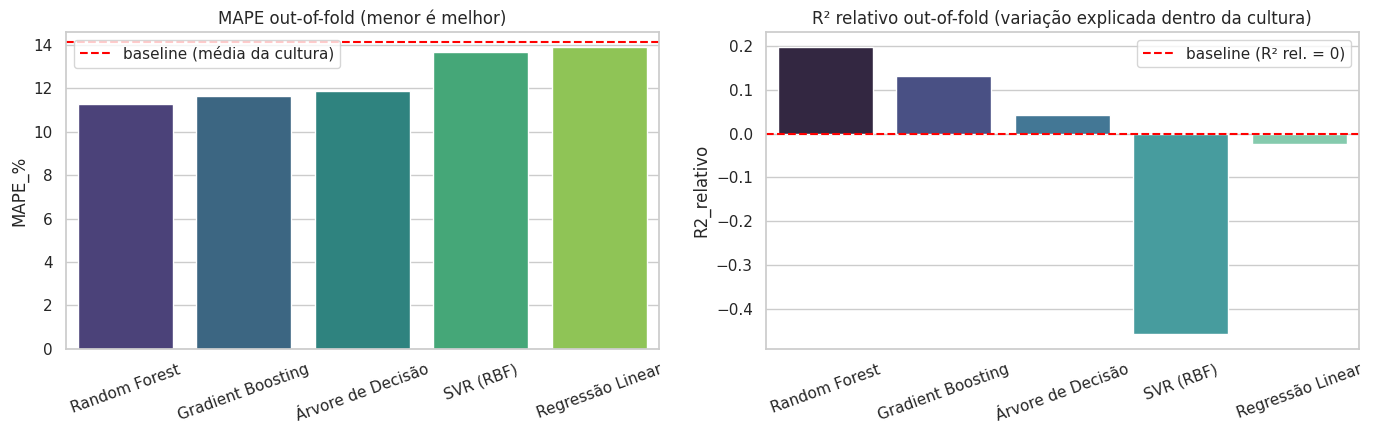

,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural",média
Random Forest,13.50,7.60,7.70,16.30,11.30
Gradient Boosting,14.90,6.80,9.00,15.90,11.70
Árvore de Decisão,14.20,8.80,8.80,15.80,11.90
SVR (RBF),17.60,8.10,9.80,19.20,13.70
Regressão Linear,16.40,7.30,13.10,18.80,13.90
Baseline (média por cultura),16.50,7.20,12.80,20.10,14.10


In [20]:
# Gráfico comparativo (out-of-fold): MAPE e R² relativo por modelo, com o baseline como referência
tab_plot = tab_oof.drop(index="Baseline (média por cultura)")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=tab_plot.index, y=tab_plot["MAPE_%"], hue=tab_plot.index, legend=False, palette="viridis", ax=axes[0])
axes[0].axhline(tab_oof.loc["Baseline (média por cultura)", "MAPE_%"], ls="--", color="red", label="baseline (média da cultura)")
axes[0].set_title("MAPE out-of-fold (menor é melhor)"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20); axes[0].legend()
sns.barplot(x=tab_plot.index, y=tab_plot["R2_relativo"], hue=tab_plot.index, legend=False, palette="mako", ax=axes[1])
axes[1].axhline(0, color="red", ls="--", label="baseline (R² rel. = 0)")
axes[1].set_title("R² relativo out-of-fold (variação explicada dentro da cultura)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=20); axes[1].legend()
plt.tight_layout(); plt.show()

# MAPE por cultura (39 previsões out-of-fold por cultura)
def mape_por_cultura(preds):
    '''Tabela modelo x cultura com o MAPE das previsões out-of-fold.'''
    linhas = {}
    for nome, p in preds.items():
        linhas[nome] = {c: 100 * mean_absolute_percentage_error(y[df.cultura == c], p[df.cultura == c]) for c in sorted(df.cultura.unique())}
    t = pd.DataFrame(linhas).T
    t["média"] = t.mean(axis=1)
    return t.sort_values("média")

mape_cultura = mape_por_cultura(preds_oof)
display(mape_cultura.round(1))

### 7.4 Diagnóstico do melhor modelo
Selecionamos o melhor algoritmo pelo **MAPE out-of-fold** (critério mais estável e interpretável para o negócio: erro percentual médio na previsão do rendimento).

Melhor modelo: Random Forest | hiperparâmetros (holdout): {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


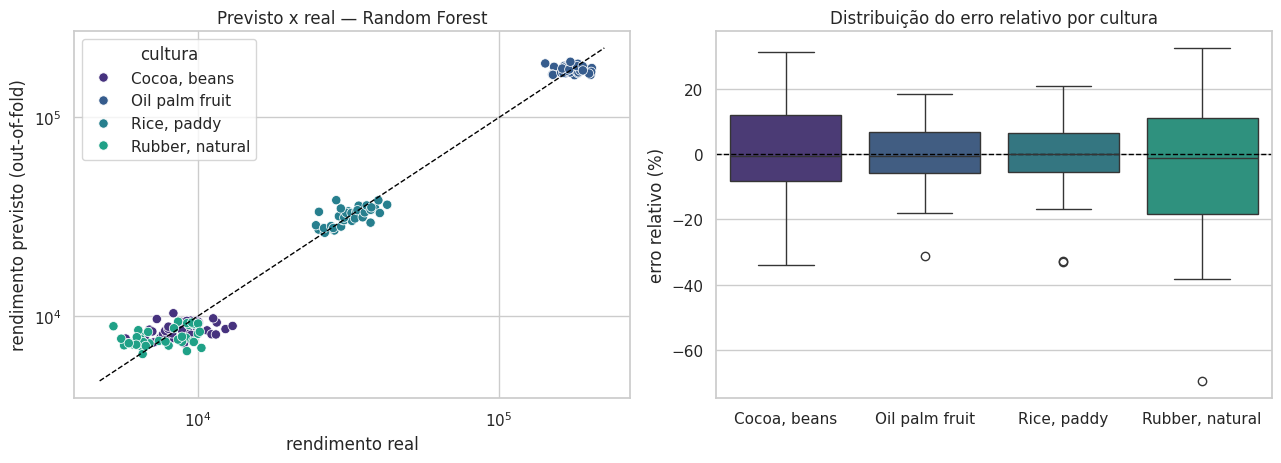

In [21]:
# Melhor modelo pelo MAPE out-of-fold (excluindo o baseline)
melhor_nome = tab_plot["MAPE_%"].idxmin()
melhor_modelo = ajustados[melhor_nome]                      # versão treinada no holdout (para os gráficos de teste)
pred_melhor_te = pd.Series(melhor_modelo.predict(X_te), index=X_te.index)
pred_melhor_oof = preds_oof[melhor_nome]
print(f"Melhor modelo: {melhor_nome} | hiperparâmetros (holdout): {tab_holdout.loc[melhor_nome, 'hiperparâmetros']}")

# Previsto x real (out-of-fold, 156 pontos) em escala log e resíduos relativos por cultura
res_rel = 100 * (y - pred_melhor_oof) / y
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(x=y, y=pred_melhor_oof, hue=df["cultura"], s=45, ax=axes[0])
lim = [y.min() * 0.9, y.max() * 1.1]
axes[0].plot(lim, lim, "k--", lw=1); axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("rendimento real"); axes[0].set_ylabel("rendimento previsto (out-of-fold)"); axes[0].set_title(f"Previsto x real — {melhor_nome}")
sns.boxplot(x=df["cultura"], y=res_rel, hue=df["cultura"], legend=False, ax=axes[1]); axes[1].axhline(0, c="k", ls="--", lw=1)
axes[1].set_ylabel("erro relativo (%)"); axes[1].set_xlabel(""); axes[1].set_title("Distribuição do erro relativo por cultura")
plt.tight_layout(); plt.show()

,aumento médio do RMSE ao permutar
umidade_especifica,-188.00
precipitacao,36.00
umidade_relativa,42.00
temperatura,714.00
cultura,"92,951.00"


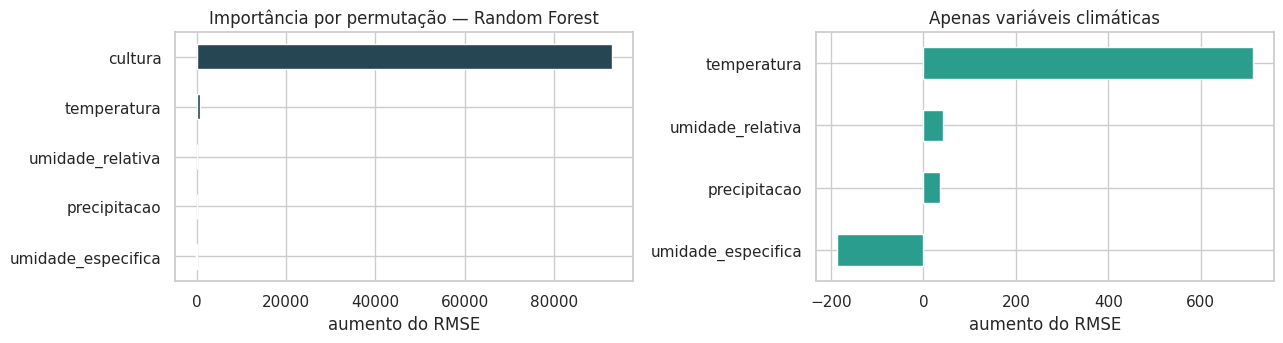

,coeficiente (log),efeito aprox. (%)
num__precipitacao,0.07,7.50
num__umidade_especifica,0.43,54.30
num__umidade_relativa,-0.41,-33.50
num__temperatura,-0.43,-35.10


In [22]:
# Importância por permutação no holdout (agnóstica ao algoritmo): quanto o RMSE piora ao embaralhar cada atributo
perm = permutation_importance(melhor_modelo, X_te, y_te, n_repeats=30, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
display(imp.to_frame("aumento médio do RMSE ao permutar").round(0))

# Importância por permutação SEM a cultura (só as climáticas), para enxergar a hierarquia entre elas
imp_clima = imp.drop("cultura")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
imp.plot.barh(ax=axes[0], color="#264653"); axes[0].set_title(f"Importância por permutação — {melhor_nome}"); axes[0].set_xlabel("aumento do RMSE")
imp_clima.plot.barh(ax=axes[1], color="#2a9d8f"); axes[1].set_title("Apenas variáveis climáticas"); axes[1].set_xlabel("aumento do RMSE")
plt.tight_layout(); plt.show()

# Coeficientes da Regressão Linear em log: efeito percentual aproximado de +1 desvio-padrão de cada variável climática
lin = ajustados["Regressão Linear"]
nomes_feat = lin.named_steps["prep"].get_feature_names_out()
coef_log = pd.Series(lin.named_steps["modelo"].regressor_.coef_, index=nomes_feat)
efeito_pct = (np.exp(coef_log) - 1) * 100
display(pd.DataFrame({"coeficiente (log)": coef_log.round(3), "efeito aprox. (%)": efeito_pct.round(1)}).loc[[c for c in nomes_feat if c.startswith("num__")]])

### 7.5 Experimento adicional: o componente temporal
A EDA e a clusterização sugeriram uma tendência ao longo da sequência de cenários. Para quantificar o quanto ela importa, repetimos a validação aninhada dos cinco algoritmos acrescentando a posição do cenário (`cenario`) como atributo. **Este experimento não substitui os modelos oficiais** (o enunciado pede previsão a partir das condições climáticas), mas dimensiona a principal limitação da base.

In [23]:
# Mesma validação aninhada, agora com clima + cultura + posição na sequência
t_exp = time.time()
preds_tempo, media_tempo = avaliar_oof(FEATURES + ["cenario"], CLIMA + ["cenario"])
tab_tempo = pd.DataFrame({nome: metricas(y, p, media_tempo) for nome, p in preds_tempo.items()}).T.astype(float)
print(f"Experimento concluído em {time.time() - t_exp:,.0f} s")

# Comparação lado a lado: apenas clima (oficial) x clima + tendência temporal
comparacao = pd.concat({"MAPE_% (só clima)": tab_oof["MAPE_%"], "MAPE_% (clima + tempo)": tab_tempo["MAPE_%"],
                        "R2_rel (só clima)": tab_oof["R2_relativo"], "R2_rel (clima + tempo)": tab_tempo["R2_relativo"]}, axis=1)
display(comparacao.sort_values("MAPE_% (clima + tempo)").round(3))

Experimento concluído em 7 s


,MAPE_% (só clima),MAPE_% (clima + tempo),R2_rel (só clima),R2_rel (clima + tempo)
Random Forest,11.27,8.23,0.20,0.51
Gradient Boosting,11.67,9.04,0.13,0.43
Árvore de Decisão,11.89,9.74,0.04,0.34
Regressão Linear,13.89,12.99,-0.02,0.04
SVR (RBF),13.70,14.11,-0.46,-0.85
Baseline (média por cultura),14.15,14.15,-0.00,-0.00


**Achados da modelagem**

- **O clima medido tem poder preditivo real, porém modesto.** Na validação aninhada (39 cenários nunca vistos), Random Forest e Gradient Boosting reduzem o erro percentual médio de 14,2% (baseline, média da cultura) para 11,3% e 11,7%, e explicam 20% e 13% da variação do rendimento *dentro* de cada cultura (R² relativo). A Árvore de Decisão fica logo atrás (11,9%). Regressão Linear (13,9%) e SVR (13,7%) praticamente empatam com o baseline: a relação clima-rendimento é não linear e muda de sinal entre culturas (temperatura ajuda o arroz e prejudica a borracha), algo que os modelos de árvore capturam com facilidade e um modelo linear aditivo não.
- **Uma única divisão treino/teste é frágil com 39 cenários.** No holdout de 8 cenários o ranking muda (Gradient Boosting tem o menor MAPE, 12,3%, e a Regressão Linear o menor RMSE, puxado pelo dendê), e vários modelos ficam abaixo do baseline. A validação aninhada, que usa todos os cenários, é a referência para as conclusões.
- **O R² global (≈ 0,98–0,99) não deve ser usado para escolher modelo**: ele reflete a separação entre culturas, que qualquer modelo com a variável `cultura` acerta. O baseline também tem R² global de 0,99. Por isso a decisão é tomada pelo MAPE e pelo R² relativo.
- Por cultura, o ganho do Random Forest sobre o baseline é maior no **arroz** (MAPE de 12,8% para 7,7%) e relevante na **borracha** (20,1% para 16,3%) e no **cacau** (16,5% para 13,5%); no **dendê** não há ganho (7,2% vs. 7,6%), coerente com a EDA: é a cultura com menor relação com o clima medido.
- A importância por permutação confirma a hierarquia: `cultura` domina de longe; entre as climáticas, a **temperatura** é a única com contribuição clara, precipitação e umidade relativa contribuem pouco e a umidade específica não ajuda (importância negativa, isto é, ruído para o modelo). Os coeficientes da Regressão Linear em log ilustram a **multicolinearidade** do clima: umidade específica (+0,43), umidade relativa (-0,41) e temperatura (-0,43) se compensam, o que torna os coeficientes individuais pouco interpretáveis, mais um motivo para preferir a leitura por permutação.
- O experimento com a posição na sequência **reduz o MAPE do Random Forest para 8,2% (Gradient Boosting 9,0%) e eleva o R² relativo para 0,51 (0,43)**: cerca de metade da variação de rendimento dentro de cada cultura é explicada por uma tendência temporal (tecnologia, variedades, manejo) que não está nas variáveis climáticas. Em produção, a FarmTech deve incorporar ano-safra e informações de manejo aos atributos.

## 8. Conclusões

### 8.1 Principais achados
1. **Estrutura da base:** 39 cenários climáticos observados para 4 culturas em uma mesma localidade de clima tropical úmido e estável (temperatura 25,6–26,8 °C; umidade relativa 82–86%). A cultura explica a maior parte da variação do rendimento; o clima explica a variação *dentro* de cada cultura.
2. **Unidades:** os valores de rendimento são compatíveis com hg/ha (padrão FAO) e não com t/ha como descrito no enunciado; a precipitação é acumulado anual, não diário. Registramos a inconsistência e mantivemos a escala original na modelagem.
3. **Outliers:** não há valores discrepantes de rendimento por IQR ou z-score; Isolation Forest e DBSCAN apenas destacam os anos climáticos extremos (cenários 2, 4, 28, 39 e vizinhos), que decidimos manter.
4. **Tendências (clusterização):** três regimes climáticos. O regime quente favorece o arroz (+11%) e penaliza a borracha (-13%); o regime seco e mais fresco faz o inverso (borracha +14%, arroz -16%); o regime úmido é neutro. Não existe "ano bom" universal, o que sustenta a **diversificação de culturas** como proteção climática para a fazenda.
5. **Previsão:** entre os cinco algoritmos, os modelos de árvore (Random Forest, Gradient Boosting e Árvore de Decisão) superam o baseline em cenários nunca vistos; o Random Forest é o melhor, com erro percentual médio de 11,3% (baseline 14,2%) e R² relativo de 0,20. Regressão Linear e SVR empatam com o baseline. A temperatura é a variável climática mais útil.
6. **Tendência temporal:** incluir a posição na sequência reduz o erro do Random Forest para 8,2% e eleva o R² relativo para 0,51, mostrando que cerca de metade da variação de rendimento dentro de cada cultura é tecnológica/temporal, não climática.

### 8.2 Pontos fortes do trabalho
- Pipeline de ML completo e reprodutível: semente fixa, pré-processamento dentro do pipeline, alvo em log, separação **por cenário climático** (sem vazamento do "ano" entre culturas), busca de hiperparâmetros com validação cruzada por grupos e validação aninhada para estimativas estáveis.
- Métricas lidas de forma crítica: baseline por cultura, R² relativo, MAPE por cultura e discussão explícita do R² global inflado.
- Combinação de técnicas não supervisionadas (K-Means, hierárquico, DBSCAN, Isolation Forest, PCA) com validação de k por silhueta e dendrograma, e leitura de negócio dos regimes.
- Achados traduzidos em linguagem de negócio para a FarmTech, incluindo os cuidados de interpretação (correlação x causalidade, confusão com a tendência temporal).

### 8.3 Limitações
- **Tamanho da amostra:** 156 registros, mas apenas 39 cenários climáticos independentes. Intervalos de erro são largos; diferenças pequenas entre modelos não são estatisticamente conclusivas.
- **Variáveis ausentes:** o enunciado menciona condições de solo, mas a base só traz clima. Não há ano, variedade, adubação, irrigação ou pragas, fatores centrais para o rendimento.
- **Tendência temporal não modelada nos modelos oficiais:** a sequência carrega um componente tecnológico (seção 7.5). Temperatura e umidade específica também crescem ao longo da série, então parte do efeito atribuído ao clima pode ser tendência.
- **Clima idêntico entre culturas e faixa climática estreita:** os modelos aprendem um "ajuste climático" em torno da média de cada cultura, para uma única localidade. Generalizar para outra fazenda ou região exigiria novos dados e novo treinamento.
- **Inconsistência de unidades** no enunciado versus dados, que pode induzir erros de interpretação por quem usar as previsões sem ler esta nota.

### 8.4 Próximos passos
- Coletar dados por talhão com sensores (a API hospedada na nuvem, tema da Entrega 2, é o primeiro passo): solo, irrigação e fenologia, além do clima.
- Incluir a dimensão temporal (ano-safra) e testar atributos de tendência ou modelos de séries temporais.
- Publicar o melhor modelo como serviço na região São Paulo da AWS (latência e LGPD), com monitoramento de deriva de dados e retreinamento periódico.

In [24]:
# Tempo total de execução do notebook (referência para quem for corrigir)
print(f"Execução concluída em {time.time() - T0:,.1f} segundos.")

Execução concluída em 22.5 segundos.


## 9. Referências
- FIAP. *Fase 4 — Cap. 13: Modelagem de Dados com Regressão Supervisionada.* Curso de Inteligência Artificial, 2026.
- FIAP. *Fase 5 — Cap. 10: Machine Learning Sem Supervisão: Uma Jornada pela Descoberta de Dados.* Curso de Inteligência Artificial, 2026.
- Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python.* JMLR 12, 2011. Documentação: https://scikit-learn.org/stable/
- FAO. *FAOSTAT — Crops and livestock products (yield, hg/ha).* https://www.fao.org/faostat/
- Géron, A. *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras e TensorFlow.* Alta Books, 2021.
- Tukey, J. W. *Exploratory Data Analysis.* Addison-Wesley, 1977 (critério IQR).
- Liu, F. T.; Ting, K. M.; Zhou, Z.-H. *Isolation Forest.* ICDM, 2008.
- Ester, M. et al. *A Density-Based Algorithm for Discovering Clusters (DBSCAN).* KDD, 1996.